# Heteroscedastic Bayes by Backprop on 1D Advection-Diffusion-Reaction

This notebook uses a manufactured 1D advection-diffusion-reaction field to show how a Bayesian neural network can learn both **model uncertainty** and **input-dependent observation noise**.

We learn the pointwise map

$$
(x, a, b, D, v, r) \mapsto u(x)
$$

and use a heteroscedastic Gaussian likelihood so the network predicts both a mean and a variance.


In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[1]
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


In [2]:
import math
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import HeteroscedasticBayesByBackpropRegressor, predict_vi_uq, vi_elbo_step


## Manufactured ADR dataset

We interpret the underlying physics as a steady advection-diffusion-reaction equation,

$$
-D u''(x) + v u'(x) + r u(x) = s(x), \qquad x \in [0,1].
$$

Instead of solving the PDE numerically in every cell, we use a manufactured smooth solution family and inject spatially varying observation noise. This keeps the notebook light while preserving the scientific meaning of advection, diffusion, and reaction parameters.


In [3]:
torch.manual_seed(0)

x_grid = torch.linspace(0.0, 1.0, 80).unsqueeze(-1)

def exact_solution(x, a, b, D, v, r):
    return a * torch.exp(-D * x) * torch.sin(math.pi * x) + b * x * (1.0 - x) * (1.0 + 0.2 * v - 0.1 * r)

def noise_scale(x):
    return 0.01 + 0.04 * torch.exp(-80.0 * (x - 0.65) ** 2)

def build_dataset(n_functions, ood=False):
    rows = []
    targets = []
    noise = []
    for _ in range(n_functions):
        if ood:
            a = torch.empty(1).uniform_(1.2, 2.0).item()
            b = torch.empty(1).uniform_(0.6, 1.1).item()
            D = torch.empty(1).uniform_(0.05, 0.15).item()
            v = torch.empty(1).uniform_(1.2, 2.0).item()
            r = torch.empty(1).uniform_(0.8, 1.4).item()
        else:
            a = torch.empty(1).uniform_(0.4, 1.1).item()
            b = torch.empty(1).uniform_(0.1, 0.6).item()
            D = torch.empty(1).uniform_(0.1, 0.3).item()
            v = torch.empty(1).uniform_(0.2, 1.0).item()
            r = torch.empty(1).uniform_(0.1, 0.8).item()
        x = x_grid
        u = exact_solution(x, a, b, D, v, r)
        sig = noise_scale(x)
        y = u + sig * torch.randn_like(u)
        features = torch.cat(
            [
                x,
                torch.full_like(x, a),
                torch.full_like(x, b),
                torch.full_like(x, D),
                torch.full_like(x, v),
                torch.full_like(x, r),
            ],
            dim=1,
        )
        rows.append(features)
        targets.append(y)
        noise.append(sig)
    return torch.cat(rows, dim=0), torch.cat(targets, dim=0), torch.cat(noise, dim=0)

x_train, y_train, sigma_train = build_dataset(96, ood=False)
x_val, y_val, sigma_val = build_dataset(24, ood=False)
x_test, y_test, sigma_test = build_dataset(24, ood=False)
x_ood, y_ood, sigma_ood = build_dataset(24, ood=True)

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=256)


## Train the heteroscedastic Bayes-by-Backprop regressor

The ELBO combines the Gaussian NLL from the heteroscedastic head and the KL regularization from the Bayesian weights.


In [4]:
model = HeteroscedasticBayesByBackpropRegressor(input_dim=6, hidden_dims=(64, 64), activation="tanh", prior_sigma=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

history = {"train": [], "val": []}
for _ in range(60):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss, _, _ = vi_elbo_step(model, xb, yb, num_batches=len(train_loader), kl_weight=0.01, mc_samples=1)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        n_items = 0
        for xb, yb in val_loader:
            loss, _, _ = vi_elbo_step(model, xb, yb, num_batches=len(train_loader), kl_weight=0.01, mc_samples=4)
            val_loss += loss.item() * yb.numel()
            n_items += yb.numel()
    history["val"].append(val_loss / n_items)


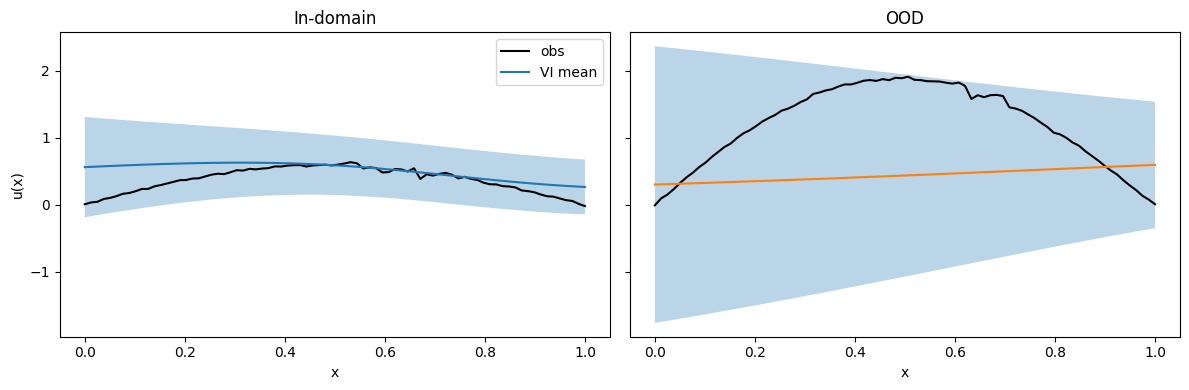

In [5]:
uq_test = predict_vi_uq(model, x_test, n_samples=40)
uq_ood = predict_vi_uq(model, x_ood, n_samples=40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
idx = slice(0, x_grid.shape[0])
axes[0].plot(x_test[idx, 0], y_test[idx, 0], color="black", label="obs")
axes[0].plot(x_test[idx, 0], uq_test.mean[idx, 0], color="tab:blue", label="VI mean")
test_std = uq_test.total_var[idx, 0].sqrt()
axes[0].fill_between(x_test[idx, 0], uq_test.mean[idx, 0] - 2 * test_std, uq_test.mean[idx, 0] + 2 * test_std, alpha=0.3)
axes[0].set_title("In-domain")
axes[1].plot(x_ood[idx, 0], y_ood[idx, 0], color="black", label="obs")
axes[1].plot(x_ood[idx, 0], uq_ood.mean[idx, 0], color="tab:orange", label="VI mean")
ood_std = uq_ood.total_var[idx, 0].sqrt()
axes[1].fill_between(x_ood[idx, 0], uq_ood.mean[idx, 0] - 2 * ood_std, uq_ood.mean[idx, 0] + 2 * ood_std, alpha=0.3)
axes[1].set_title("OOD")
for ax in axes:
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].legend(loc="best")
plt.tight_layout()
